# 05 — Inference Test

Production-style inference, multi-ticker dashboard, sensitivity analysis.

In [1]:
!pip install -q pytorch-forecasting==1.1.1 lightning numpy==1.26.4 pandas==2.1.4
from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 29.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.1.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 

In [1]:
import os, json, pickle, time, warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
torch.set_float32_matmul_precision('medium')

import lightning.pytorch as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer

plt.style.use('seaborn-v0_8-whitegrid')

DRIVE_DATA = '/content/drive/MyDrive/predictamarket/data'
MODEL_DIR = '/content/drive/MyDrive/predictamarket/models'
INFER_DIR = '/content/drive/MyDrive/predictamarket/inference'
os.makedirs(INFER_DIR, exist_ok=True)

In [ ]:
CHECKPOINT_NAME = "tft-epoch=05-val_loss=9.3008.ckpt" 

import re as _re
_ckpts_avail = sorted([f for f in os.listdir(MODEL_DIR) if f.endswith('.ckpt')])
if CHECKPOINT_NAME is None:
    CHECKPOINT_NAME = _ckpts_avail[-1]
assert CHECKPOINT_NAME in _ckpts_avail, f'{CHECKPOINT_NAME} not among {_ckpts_avail}'

_m = _re.search(r'epoch=?(\d+)', CHECKPOINT_NAME)
RUN_TAG = f'epoch{int(_m.group(1)):02d}' if _m else CHECKPOINT_NAME.replace('.ckpt', '')

INFER_DIR = os.path.join(INFER_DIR, RUN_TAG)
os.makedirs(INFER_DIR, exist_ok=True)

print(f'Available checkpoints ({len(_ckpts_avail)}):')
for c in _ckpts_avail:
    print(f'  {"→" if c == CHECKPOINT_NAME else " "} {c}')
print(f'\nUsing:   {CHECKPOINT_NAME}')
print(f'RUN_TAG: {RUN_TAG}')
print(f'Outputs → {INFER_DIR}')


Available checkpoints (7):
    tft-epoch=00-val_loss=8.9736.ckpt
    tft-epoch=01-val_loss=7.3249.ckpt
    tft-epoch=02-val_loss=8.8051.ckpt
    tft-epoch=03-val_loss=8.2107.ckpt
    tft-epoch=04-val_loss=9.2586.ckpt
  → tft-epoch=05-val_loss=9.3008.ckpt
    tft-epoch=06-val_loss=9.4489.ckpt

Using:   tft-epoch=05-val_loss=9.3008.ckpt
RUN_TAG: epoch05
Outputs → /content/drive/MyDrive/predictamarket/inference/epoch05


In [ ]:
with open(os.path.join(MODEL_DIR, 'config.json')) as f:
    config = json.load(f)
with open(os.path.join(MODEL_DIR, 'training_dataset_params.pkl'), 'rb') as f:
    dataset_params = pickle.load(f)

# Get TFT-known tickers
known_tickers = list(dataset_params['categorical_encoders']['__group_id__ticker'].classes_.keys())
max_encoder_length = dataset_params.get('max_encoder_length', 60)

import pyarrow.parquet as pq
import gc


dfs = []
for fname in ['train.parquet', 'val.parquet', 'test.parquet']:
    fpath = os.path.join(DRIVE_DATA, fname)
    if os.path.exists(fpath):
        table = pq.read_table(fpath, filters=[('ticker', 'in', known_tickers)])
        dfs.append(table.to_pandas())
        del table

full_df = pd.concat(dfs, ignore_index=True)
del dfs; gc.collect()

keep_rows = max_encoder_length + config['max_prediction_length'] + 50
full_df = full_df.groupby('ticker').tail(keep_rows).copy()

for col in config['static_categoricals'] + config['time_varying_known_categoricals']:
    full_df[col] = full_df[col].astype(str)
full_df['time_idx'] = full_df['time_idx'].astype(int)
full_df[config['time_varying_unknown_reals']] = full_df[config['time_varying_unknown_reals']].fillna(0)
full_df.replace([np.inf, -np.inf], np.nan, inplace=True)
full_df.dropna(subset=['Close'], inplace=True)
full_df.drop(full_df[full_df['Close'] <= 0].index, inplace=True)

ckpts = sorted([f for f in os.listdir(MODEL_DIR) if f.endswith('.ckpt')])
model = TemporalFusionTransformer.load_from_checkpoint(
    os.path.join(MODEL_DIR, CHECKPOINT_NAME), weights_only=False
)
model.eval()
print(f'Loaded: {CHECKPOINT_NAME}')

params = dataset_params.copy()
params['allow_missing_timesteps'] = True
training_ds = TimeSeriesDataSet.from_parameters(params, full_df)

print(f'Model loaded. Data: {full_df.shape}')
print(f'Tickers: {full_df["ticker"].nunique()}')

Loaded: tft-epoch=05-val_loss=9.3008.ckpt
Model loaded. Data: (52800, 115)
Tickers: 400


## Inference function

In [ ]:
def run_inference(ticker, full_df, config, dataset_params, model, training_ds):
    """Run inference for a single ticker. Uses pre-built training_ds for speed."""
    lookback = config['max_encoder_length'] + config['max_prediction_length']
    data = full_df[full_df['ticker'] == ticker].sort_values('time_idx').tail(lookback).reset_index(drop=True)

    if len(data) < config['max_encoder_length']:
        return {'error': f'Not enough data for {ticker}: {len(data)} rows'}

    infer_ds = TimeSeriesDataSet.from_dataset(training_ds, data, predict=True, stop_randomization=True)
    infer_dl = infer_ds.to_dataloader(train=False, batch_size=1, num_workers=0)

    raw = model.predict(infer_dl, mode='raw')
    q = raw['prediction'][0].detach().cpu().numpy()

    current = data['Close'].iloc[-1]
    last_date = pd.to_datetime(data['Date'].iloc[-1])

    return {
        'ticker': ticker, 'current_close': float(current), 'last_date': last_date,
        'pred_1d': float(q[0, 3]), 'pred_1w': float(q[4, 3]) if q.shape[0] > 4 else None,
        'pred_1m': float(q[21, 3]) if q.shape[0] > 21 else None,
        'ci_lower_1d': float(q[0, 1]), 'ci_upper_1d': float(q[0, 5]),
        'full_median': q[:, 3], 'full_lower': q[:, 1], 'full_upper': q[:, 5],
    }

## Single Ticker Demo

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

AAPL (8.00s):
  Current: $255.92
  1D: $262.16 [247.67, 275.20]
  1W: $259.45
  1M: $253.19


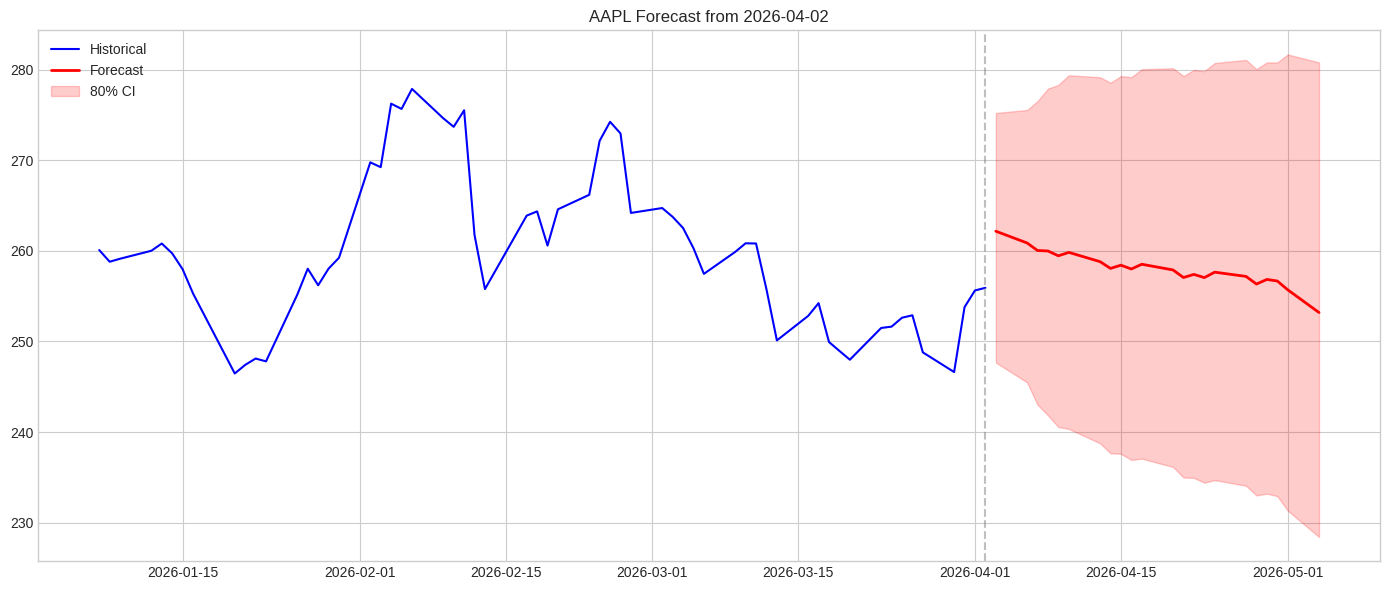

In [5]:
t0 = time.time()
r = run_inference('aapl', full_df, config, dataset_params, model, training_ds)
print(f'AAPL ({time.time()-t0:.2f}s):')
print(f'  Current: ${r["current_close"]:.2f}')
print(f'  1D: ${r["pred_1d"]:.2f} [{r["ci_lower_1d"]:.2f}, {r["ci_upper_1d"]:.2f}]')
print(f'  1W: ${r["pred_1w"]:.2f}' if r['pred_1w'] else '')
print(f'  1M: ${r["pred_1m"]:.2f}' if r['pred_1m'] else '')

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
hist = full_df[full_df['ticker']=='aapl'].sort_values('Date').tail(60)
ax.plot(pd.to_datetime(hist['Date']), hist['Close'], 'b-', lw=1.5, label='Historical')
fd = pd.bdate_range(r['last_date'] + pd.Timedelta(days=1), periods=len(r['full_median']))
ax.plot(fd, r['full_median'], 'r-', lw=2, label='Forecast')
ax.fill_between(fd, r['full_lower'], r['full_upper'], alpha=0.2, color='red', label='80% CI')
ax.axvline(r['last_date'], color='gray', ls='--', alpha=0.5)
ax.set_title(f'AAPL Forecast from {r["last_date"].date()}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(INFER_DIR, 'aapl_forecast.png'), dpi=150)
plt.show()

## Multi-Ticker dashboard (Top 50)

In [6]:
# Run for tickers that are in TFT-known set
top_tickers = [t for t in ['aapl','msft','nvda','amzn','goog','jpm','xom','v','cost',
    'jnj','abbv','wmt','crm','amd','orcl','cvx','mrk','ko','pep','lly','avgo',
    'dis','nke','intc','csco','ibm','ge','cat','ba','mmm','axp','gs','ms',
    'c','wfc','usb','pnc','schw','bk','tfc','met','aig','pru','all',
    'hd','low','tgt','tjx','rost','dg'] if t in known_tickers]

print(f'Tickers in model: {len(top_tickers)}')

dashboard = []
t0 = time.time()
for ticker in top_tickers:
    try:
        r = run_inference(ticker, full_df, config, dataset_params, model, training_ds)
        if 'error' in r:
            print(f'  {ticker}: {r["error"]}')
            continue
        c = r['current_close']
        dashboard.append({
            'Ticker': ticker.upper(),
            'Sector': config['sectors'].get(ticker, ''),
            'Current': f'${c:.2f}',
            'Pred 1D': f'${r["pred_1d"]:.2f}',
            'Chg 1D': f'{(r["pred_1d"]/c-1)*100:+.2f}%',
            'Pred 1M': f'${r["pred_1m"]:.2f}' if r['pred_1m'] else '-',
            'Chg 1M': f'{(r["pred_1m"]/c-1)*100:+.2f}%' if r['pred_1m'] else '-',
            'Direction': 'UP' if r['pred_1d'] > c else 'DOWN',
            '_sort': (r['pred_1m']/c-1) if r['pred_1m'] else 0,
        })
    except Exception as e:
        print(f'  {ticker}: {e}')

dash_df = pd.DataFrame(dashboard).sort_values('_sort', ascending=False)
print(f'\nDashboard ({time.time()-t0:.1f}s total, {len(dashboard)} tickers)\n')
display(dash_df.drop(columns='_sort'))
dash_df.drop(columns='_sort').to_csv(os.path.join(INFER_DIR, 'dashboard.csv'), index=False)

Tickers in model: 40


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch


Dashboard (45.1s total, 40 tickers)



,Ticker,Sector,Current,Pred 1D,Chg 1D,Pred 1M,Chg 1M,Direction
19,NKE,Consumer Cyclical,$44.19,$58.88,+33.24%,$53.08,+20.13%,UP
36,LOW,Consumer Cyclical,$231.03,$259.34,+12.25%,$248.42,+7.53%,UP
7,ABBV,Healthcare,$208.84,$231.42,+10.81%,$213.87,+2.41%,UP
14,KO,Consumer Defensive,$76.72,$78.71,+2.59%,$76.90,+0.23%,UP
33,AIG,Financial Services,$75.42,$77.43,+2.67%,$75.44,+0.03%,UP
35,ALL,Financial Services,$207.03,$212.64,+2.71%,$206.96,-0.04%,UP
0,AAPL,Technology,$255.92,$262.16,+2.44%,$253.19,-1.07%,UP
1,MSFT,Technology,$373.46,$403.21,+7.97%,$367.74,-1.53%,UP
15,PEP,Consumer Defensive,$157.01,$162.09,+3.24%,$153.57,-2.19%,UP
16,LLY,Healthcare,$935.58,$975.66,+4.28%,$911.98,-2.52%,UP


## Sentiment sensitivity

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

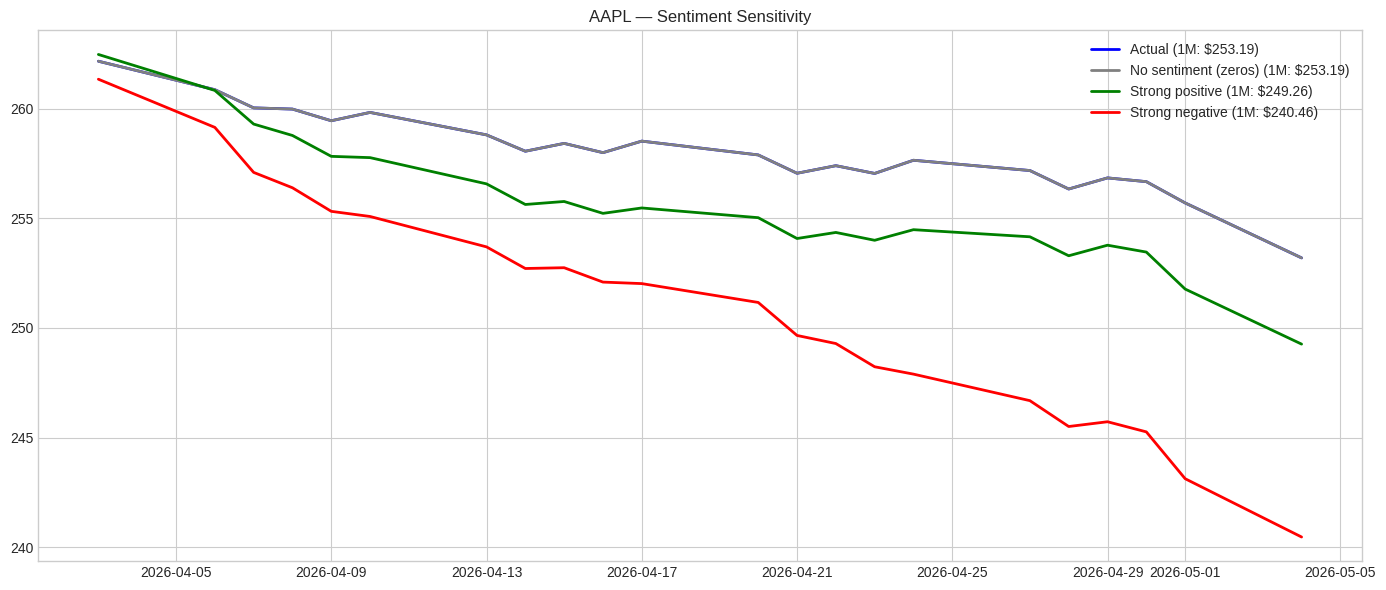

In [7]:
n_sent = config.get('n_sentiment_components', 32)
sent_cols = [f'sent_{i}' for i in range(n_sent)] + ['news_count']

scenarios = {
    'Actual': None,
    'No sentiment (zeros)': {c: 0.0 for c in sent_cols},
    'Strong positive': {**{f'sent_{i}': (2.0 if i < 5 else 0.0) for i in range(n_sent)}, 'news_count': 20.0},
    'Strong negative': {**{f'sent_{i}': (-2.0 if i < 5 else 0.0) for i in range(n_sent)}, 'news_count': 20.0},
}

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['blue', 'gray', 'green', 'red']

for (name, overrides), color in zip(scenarios.items(), colors):
    mod = full_df.copy()
    if overrides:
        mask = mod['ticker'] == 'aapl'
        for col, val in overrides.items():
            if col in mod.columns:
                mod.loc[mask, col] = val
    try:
        # Rebuild training_ds for modified data
        mod_training_ds = TimeSeriesDataSet.from_parameters(params, mod)
        r = run_inference('aapl', mod, config, dataset_params, model, mod_training_ds)
        if 'error' in r:
            print(f'{name}: {r["error"]}')
            continue
        fd = pd.bdate_range(r['last_date'] + pd.Timedelta(days=1), periods=len(r['full_median']))
        label = f'{name} (1M: ${r["pred_1m"]:.2f})' if r['pred_1m'] else name
        ax.plot(fd, r['full_median'], '-', color=color, lw=2, label=label)
    except Exception as e:
        print(f'{name}: {e}')

ax.set_title('AAPL — Sentiment Sensitivity')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(INFER_DIR, 'sentiment_sensitivity.png'), dpi=150)
plt.show()

In [8]:
# Timing
times = []
for _ in range(5):
    t0 = time.time()
    _ = run_inference('aapl', full_df, config, dataset_params, model, training_ds)
    times.append(time.time() - t0)

print('=== Benchmarks ===')
print(f'Inference time: {np.mean(times):.3f}s +/- {np.std(times):.3f}s')
print(f'Model params: {model.size()/1e6:.2f}M')
ckpt_size = os.path.getsize(os.path.join(MODEL_DIR, CHECKPOINT_NAME)) / 1e6
print(f'Checkpoint: {CHECKPOINT_NAME} ({ckpt_size:.1f} MB)')

# Export sample predictions
samples = []
for t in ['aapl', 'abt', 'agco', 'chd', 'abm']:
    if t not in known_tickers: continue
    try:
        r = run_inference(t, full_df, config, dataset_params, model, training_ds)
        if 'error' in r: continue
        samples.append({
            'ticker': t, 'last_date': str(r['last_date'].date()),
            'current_close': r['current_close'],
            'forecast': {
                '1d': {'median': r['pred_1d'], 'lower': r['ci_lower_1d'], 'upper': r['ci_upper_1d']},
                '1w': {'median': r['pred_1w']} if r['pred_1w'] else None,
                '1m': {'median': r['pred_1m']} if r['pred_1m'] else None,
            }
        })
    except: pass

with open(os.path.join(INFER_DIR, 'sample_predictions.json'), 'w') as f:
    json.dump(samples, f, indent=2)

# API contract
contract = {
    'model': 'TFT (hidden_size=256, 4 heads)',
    'checkpoint': CHECKPOINT_NAME,
    'tickers': len(known_tickers),
    'input_lookback': config['max_encoder_length'],
    'output_horizon': config['max_prediction_length'],
    'quantiles': [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98],
    'features': {
        'time_series': ['OHLCV', 'log_return', 'volatility', 'MA', 'RSI'],
        'sentiment': f'FinBERT 768d -> PCA {config.get("n_sentiment_components", 32)}d',
        'tables': config.get('table_metrics', []),
        'macro': config.get('macro_cols', []),
    },
    'artifacts': [f for f in os.listdir(MODEL_DIR)],
}
with open(os.path.join(INFER_DIR, 'api_contract.json'), 'w') as f:
    json.dump(contract, f, indent=2)

print(f'\n=== All Done ===')
print(f'Artifacts: {INFER_DIR}')

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

=== Benchmarks ===
Inference time: 2.167s +/- 1.207s
Model params: 16.27M
Checkpoint: tft-epoch=05-val_loss=9.3008.ckpt (197.6 MB)


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/pr


=== All Done ===
Artifacts: /content/drive/MyDrive/predictamarket/inference/epoch05
